# Random Forests Regression Implementation

## Overview

In this notebook, I applied **Random Forests** to predict Big Five personality traits (Extraversion, Agreeableness, Conscientiousness, Neuroticism, Openness) from textual life narrative responses (Q1–Q32).

### What is a Random Forest?

A **Random Forest** is an ensemble learning method that builds many decision trees during training and outputs the **average prediction** (regression) or **majority vote** (classification) across all trees.

Each tree is trained on:
- A **random bootstrap sample** of the data (bagging)
- A **random subset of features** at each split

This randomness makes the forest more robust and less prone to overfitting than a single decision tree.

### Why Random Forests for Personality Prediction?
- Handles high-dimensional TF-IDF text features well
- Robust to noisy features (many TF-IDF terms are irrelevant)
- Provides **feature importance** — tells us which words/phrases predict personality
- No need to scale features

### Pipeline
```
Raw narrative text (Q columns)
        ↓
TF-IDF Vectorization (text → numeric features)
        ↓
Random Forest Regressor (predict each Big Five trait)
        ↓
Evaluation (R², MAE, Cross-Validation)
        ↓
Feature Importance (which words matter most?)
```

## 1. Data preprocessing, import required packages

### Text Features (X)
All narrative columns are combined into a single text string per participant, then apply **TF-IDF** (Term Frequency–Inverse Document Frequency) to convert text into a numeric matrix.

- **TF (Term Frequency):** how often a word appears in a response
- **IDF (Inverse Document Frequency):** penalizes words that appear in almost every response (e.g., "the", "and")
- `max_features=500` keeps the 500 most informative words to avoid overfitting

### Targets (y)
Each Big Five trait score is a continuous variable (mean of item scores, scale 1–5), so this is a **regression** problem.

### Train/Test Split

Data is split into **80% training** and **20% testing**.

- The model learns patterns from the training set
- Performance is evaluated on the unseen test set
- `random_state=42` ensures reproducibility

In [15]:
import json
from pathlib import Path
import pandas as pd

# Find repo root automatically
repo_root = Path.cwd().resolve()
while not (repo_root / "BFI_2_life_narative_metadata.json").exists():
    if repo_root == repo_root.parent:
        raise FileNotFoundError("Could not find BFI_2_life_narative_metadata.json")
    repo_root = repo_root.parent

# Load data
with open(repo_root / "BFI_2_life_narative_metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

with open(repo_root / "BFI_2_life_narrative.json", "r", encoding="utf-8") as f:
    responses = json.load(f)

df = pd.DataFrame(responses)

# Reverse-code BFI items
reverse_items = metadata["reverse_code_items"]

for item in reverse_items:
    if item in df.columns:
        df[item] = 6 - df[item]

# Big Five trait means
traits = {
    key: value
    for key, value in metadata.items()
    if (
        isinstance(value, list)
        and value
        and isinstance(value[0], str)
        and value[0].startswith("Item")
        and not key.startswith(("Item", "Q", "CWB", "OCB"))
        and key != "reverse_code_items"
    )
}

for trait, items in traits.items():
    available_items = [item for item in items if item in df.columns]
    df[trait] = df[available_items].mean(axis=1)

# CWB and OCB means
cwb_cols = [f"CWB{i}" for i in range(1, 11) if f"CWB{i}" in df.columns]
ocb_cols = [f"OCB{i}" for i in range(1, 11) if f"OCB{i}" in df.columns]

df["CWB"] = df[cwb_cols].mean(axis=1)
df["OCB"] = df[ocb_cols].mean(axis=1)

# Text features
q_cols = [c for c in df.columns if isinstance(c, str) and c.startswith("Q")]

X_text = df[q_cols].copy()
X_all = X_text.fillna("").agg(" ".join, axis=1)

# Targets
big_five = [
    "Extraversion",
    "Agreeableness",
    "Conscientiousness",
    "Neuroticism",
    "Openness",
]

y = df[big_five].copy()

print("✓ Data preprocessing complete")
print("Repo root:", repo_root)
print("df shape:", df.shape)
print("X_text shape:", X_text.shape)
print("X_all shape:", X_all.shape)
print(y.describe().round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

✓ Data preprocessing complete
Repo root: /Users/cindy/cmor438_Spring2026/cmor438_Spring2026
df shape: (500, 138)
X_text shape: (500, 32)
X_all shape: (500,)
       Extraversion  Agreeableness  Conscientiousness  Neuroticism  Openness
count       500.000        500.000            500.000      500.000   500.000
mean          3.177          3.786              3.642        2.879     3.833
std           0.761          0.576              0.710        0.846     0.618
min           1.000          2.000              1.083        1.000     1.750
25%           2.667          3.417              3.167        2.333     3.417
50%           3.167          3.833              3.750        2.917     3.833
75%           3.750          4.167              4.083        3.417     4.250
max           5.000          5.000              5.000        4.917     5.000
Training samples : 400
Test samples     : 100


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV
)
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

print("✓ Imports complete")

✓ Imports complete


## 2. The Random Forest Package

Below a reusable `RandomForestPersonality` class is defined:
- TF-IDF vectorization
- Random Forest training
- Cross-validation
- Evaluation metrics
- Feature importance plots

This mirrors how scikit-learn's own estimators work, making it easy to reuse across notebooks.

In [16]:
class RandomForestPersonality:
    """
    A reusable Random Forest pipeline for predicting Big Five
    personality traits from free-text narrative responses.

    Parameters
    ----------
    n_estimators : int
        Number of trees in the forest (default: 200)
    max_features : int
        Number of TF-IDF features to keep (default: 500)
    max_depth : int or None
        Max depth of each tree. None = fully grown (default: None)
    min_samples_split : int
        Min samples required to split a node (default: 5)
    random_state : int
        Seed for reproducibility (default: 42)
    """

    def __init__(
        self,
        n_estimators=200,
        max_features_tfidf=500,
        max_depth=None,
        min_samples_split=5,
        random_state=42
    ):
        self.n_estimators = n_estimators
        self.max_features_tfidf = max_features_tfidf
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        self.pipelines = {}       # one pipeline per trait
        self.results = {}         # stores eval metrics
        self.feature_names = None

    def _build_pipeline(self):
        """Build a TF-IDF + RandomForest pipeline."""
        return Pipeline([
            ("tfidf", TfidfVectorizer(
                max_features=self.max_features_tfidf,
                stop_words="english",
                ngram_range=(1, 2)   # unigrams + bigrams
            )),
            ("rf", RandomForestRegressor(
                n_estimators=self.n_estimators,
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                random_state=self.random_state,
                n_jobs=-1            # use all CPU cores
            ))
        ])

    def fit(self, X_train, y_train):
        """
        Fit one pipeline per Big Five trait.

        Parameters
        ----------
        X_train : array-like of strings (narrative text)
        y_train : DataFrame with Big Five trait columns
        """
        for trait in y_train.columns:
            pipe = self._build_pipeline()
            pipe.fit(X_train, y_train[trait])
            self.pipelines[trait] = pipe
        print(f"✓ Trained {len(self.pipelines)} Random Forest models")
        return self

    def predict(self, X):
        """
        Predict all Big Five traits for new text data.

        Returns
        -------
        DataFrame of predictions, one column per trait
        """
        preds = {}
        for trait, pipe in self.pipelines.items():
            preds[trait] = pipe.predict(X)
        return pd.DataFrame(preds)

    def evaluate(self, X_test, y_test):
        """
        Evaluate model on test set using R² and MAE.

        Returns
        -------
        DataFrame of metrics per trait
        """
        y_pred = self.predict(X_test)
        rows = []
        for trait in y_test.columns:
            r2  = r2_score(y_test[trait], y_pred[trait])
            mae = mean_absolute_error(y_test[trait], y_pred[trait])
            rows.append({"Trait": trait, "R²": round(r2, 4), "MAE": round(mae, 4)})
            self.results[trait] = {"R²": r2, "MAE": mae}
        return pd.DataFrame(rows).set_index("Trait")

    def cross_validate(self, X, y, cv=5):
        """
        Run k-fold cross-validation for each trait.

        Parameters
        ----------
        cv : int, number of folds (default: 5)

        Returns
        -------
        DataFrame of mean ± std CV R² per trait
        """
        kf = KFold(n_splits=cv, shuffle=True, random_state=self.random_state)
        rows = []
        for trait in y.columns:
            pipe = self._build_pipeline()
            scores = cross_val_score(
                pipe, X, y[trait],
                cv=kf, scoring="r2", n_jobs=-1
            )
            rows.append({
                "Trait": trait,
                "CV Mean R²": round(scores.mean(), 4),
                "CV Std": round(scores.std(), 4),
                "All Folds": scores.round(4)
            })
            print(f"  {trait:20s} R² = {scores.mean():.4f} ± {scores.std():.4f}")
        return pd.DataFrame(rows).set_index("Trait")

    def plot_feature_importance(self, trait, top_n=20):
        """
        Plot the top N most important words for predicting a trait.

        Parameters
        ----------
        trait  : str, one of the Big Five traits
        top_n  : int, number of top features to show (default: 20)
        """
        pipe         = self.pipelines[trait]
        tfidf        = pipe.named_steps["tfidf"]
        rf           = pipe.named_steps["rf"]
        feature_names = tfidf.get_feature_names_out()
        importances  = rf.feature_importances_

        top_idx = np.argsort(importances)[::-1][:top_n]
        top_words  = feature_names[top_idx]
        top_scores = importances[top_idx]

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.barh(top_words[::-1], top_scores[::-1], color="steelblue")
        ax.set_xlabel("Feature Importance (Gini)")
        ax.set_title(f"Top {top_n} Words for Predicting {trait}")
        plt.tight_layout()
        plt.show()

    def plot_all_r2(self):
        """Bar chart of R² scores across all Big Five traits."""
        traits = list(self.results.keys())
        r2s    = [self.results[t]["R²"] for t in traits]

        colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
        fig, ax = plt.subplots(figsize=(8, 4))
        bars = ax.bar(traits, r2s, color=colors)
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_ylabel("R² Score")
        ax.set_title("Random Forest — R² per Big Five Trait (Test Set)")
        ax.set_ylim(min(min(r2s) - 0.05, -0.05), max(max(r2s) + 0.05, 0.3))
        for bar, val in zip(bars, r2s):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.3f}",
                ha="center", va="bottom", fontsize=9
            )
        plt.tight_layout()
        plt.show()


print("✓ RandomForestPersonality class defined")

✓ RandomForestPersonality class defined


## 3. Hyperparameter Tuning with GridSearchCV

Before training the final model, **Grid Search with 5-fold Cross-Validation** was used to tune the key hyperparameters.

Hyperparameters are tuned on separately for each trait. As traits have different features, obtaining the best parameters for all traits can help optimize the overall prediction.

Key parameters to tune:
| Parameter | What it controls |
|---|---|
| `n_estimators` | More trees = more stable, slower |
| `max_depth` | Deeper = more complex, risk of overfitting |
| `min_samples_split` | Higher = simpler trees, less overfitting |

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer

param_grid = {
    "rf__n_estimators":      [100, 200],
    "rf__max_depth":         [None, 10, 20],
    "rf__min_samples_split": [2, 5, 10]
}

gs_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=500, stop_words="english", ngram_range=(1, 2))),
    ("rf",    RandomForestRegressor(random_state=42, n_jobs=-1))
])

best_params = {}

for trait in big_five:
    gs = GridSearchCV(
        gs_pipeline, param_grid,
        cv=5, scoring="r2", n_jobs=-1
    )
    gs.fit(X_train, y_train[trait])
    best_params[trait] = gs.best_params_
    print(f"{trait:20s} → best R²: {gs.best_score_:.4f} | params: {gs.best_params_}")

print("\n✓ Best parameters found for all traits")

Extraversion         → best R²: 0.0961 | params: {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Agreeableness        → best R²: -0.0139 | params: {'rf__max_depth': None, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Conscientiousness    → best R²: 0.0697 | params: {'rf__max_depth': 20, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Neuroticism          → best R²: 0.0651 | params: {'rf__max_depth': None, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Openness             → best R²: 0.0212 | params: {'rf__max_depth': 20, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}

✓ Best parameters found for all traits


## 4. Train & Test Model

The full `RandomForestPersonality` model on all five traits is trained on the best parameters found above

Model is evaluated based on two metrics:

- **R² (coefficient of determination):** proportion of variance explained. R²=1 is perfect, R²=0 means the model is no better than predicting the mean. Negative R² means it's worse than the mean.
- **MAE (Mean Absolute Error):** average prediction error in the original scale (1–5). Lower is better.

In [18]:
# Build one optimized pipeline per trait
from sklearn.pipeline import Pipeline

final_pipelines = {}

for trait in big_five:
    p = best_params[trait]
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=500, stop_words="english", ngram_range=(1, 2)
        )),
        ("rf", RandomForestRegressor(
            n_estimators      = p["rf__n_estimators"],
            max_depth         = p["rf__max_depth"],
            min_samples_split = p["rf__min_samples_split"],
            random_state      = 42,
            n_jobs            = -1
        ))
    ])
    pipe.fit(X_train, y_train[trait])
    final_pipelines[trait] = pipe
    print(f"✓ Trained {trait}")

✓ Trained Extraversion
✓ Trained Agreeableness
✓ Trained Conscientiousness
✓ Trained Neuroticism
✓ Trained Openness


In [23]:
from sklearn.metrics import r2_score, mean_absolute_error

rows = []
for trait in big_five:
    y_pred_trait = final_pipelines[trait].predict(X_test)
    r2  = r2_score(y_test[trait], y_pred_trait)
    mae = mean_absolute_error(y_test[trait], y_pred_trait)
    rows.append({"Trait": trait, "R²": round(r2, 4), "MAE": round(mae, 4)})

results = pd.DataFrame(rows).set_index("Trait")
print("Test Set Performance:")
print(results)

Test Set Performance:
                       R²     MAE
Trait                            
Extraversion       0.0571  0.6022
Agreeableness     -0.0381  0.4111
Conscientiousness  0.0895  0.5761
Neuroticism        0.0480  0.7280
Openness          -0.0215  0.5452


## 4. Cross-Validation

As single train/test splits may vary a lot based on how data is specifically split. **5-fold cross-validation** gives a more reliable estimate of model performance:

1. Split data into 5 equal folds
2. Train on 4 folds, test on the remaining 1
3. Repeat 5 times (each fold is the test set once)
4. Report mean ± standard deviation of R², MAE and Pearson's r

A low std means the model is stable across different data splits.

In [28]:
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

q_cols = [c for c in df.columns if isinstance(c, str) and c.startswith("Q")]
X_all  = df[q_cols].fillna("").agg(" ".join, axis=1).reset_index(drop=True)
y_cv   = y.reset_index(drop=True)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
print("5-Fold Cross-Validation Results:")
print("-" * 45)

cv_rows = []
for trait in big_five:
    p = best_params[trait]
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=500, stop_words="english", ngram_range=(1, 2)
        )),
        ("rf", RandomForestRegressor(
            n_estimators      = p["rf__n_estimators"],
            max_depth         = p["rf__max_depth"],
            min_samples_split = p["rf__min_samples_split"],
            random_state=42, n_jobs=-1
        ))
    ])

    # Manually loop folds to collect Pearson r alongside R² and MAE
    fold_r2, fold_mae, fold_r = [], [], []
    for train_idx, test_idx in kf.split(X_all):
        X_tr, X_te = X_all.iloc[train_idx], X_all.iloc[test_idx]
        y_tr, y_te = y_cv[trait].iloc[train_idx], y_cv[trait].iloc[test_idx]

        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)

        fold_r2.append(r2_score(y_te, y_pred))
        fold_mae.append(mean_absolute_error(y_te, y_pred))
        fold_r.append(np.corrcoef(y_te, y_pred)[0, 1])

    cv_rows.append({
        "Trait":      trait,
        "CV Mean R²": round(np.mean(fold_r2),  4),
        "CV Std R²":  round(np.std(fold_r2),   4),
        "CV MAE":     round(np.mean(fold_mae),  4),
        "Pearson r":  round(np.mean(fold_r),    4),
    })
    print(f"  {trait:20s} R²={np.mean(fold_r2):.4f} ± {np.std(fold_r2):.4f}  "
          f"MAE={np.mean(fold_mae):.4f}  r={np.mean(fold_r):.4f}")

cv_results = pd.DataFrame(cv_rows).set_index("Trait")
print("\nSummary:")
print(cv_results)

5-Fold Cross-Validation Results:
---------------------------------------------
  Extraversion         R²=0.0723 ± 0.0057  MAE=0.5837  r=0.2981
  Agreeableness        R²=-0.0393 ± 0.0178  MAE=0.4639  r=0.0296
  Conscientiousness    R²=0.0757 ± 0.0303  MAE=0.5456  r=0.2916
  Neuroticism          R²=0.0566 ± 0.0223  MAE=0.6548  r=0.2601
  Openness             R²=0.0141 ± 0.0240  MAE=0.4922  r=0.1396

Summary:
                   CV Mean R²  CV Std R²  CV MAE  Pearson r
Trait                                                      
Extraversion           0.0723     0.0057  0.5837     0.2981
Agreeableness         -0.0393     0.0178  0.4639     0.0296
Conscientiousness      0.0757     0.0303  0.5456     0.2916
Neuroticism            0.0566     0.0223  0.6548     0.2601
Openness               0.0141     0.0240  0.4922     0.1396


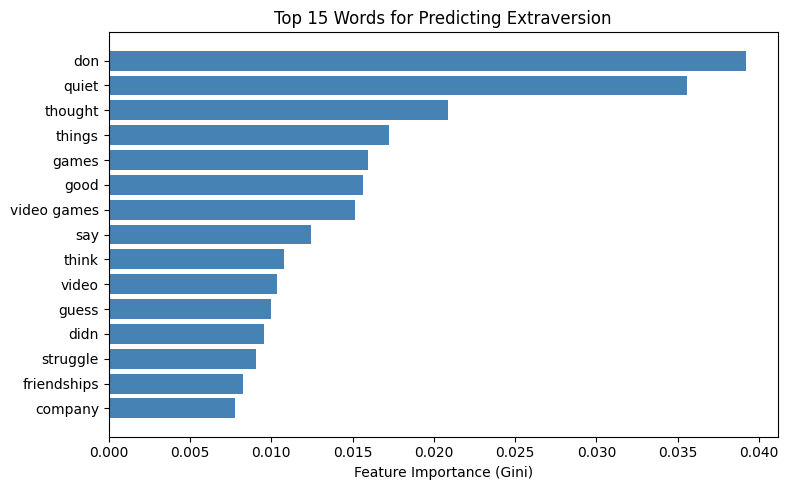

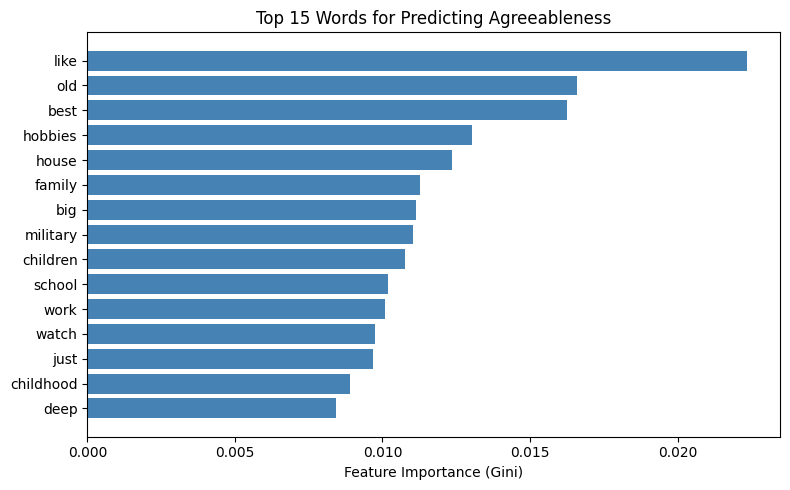

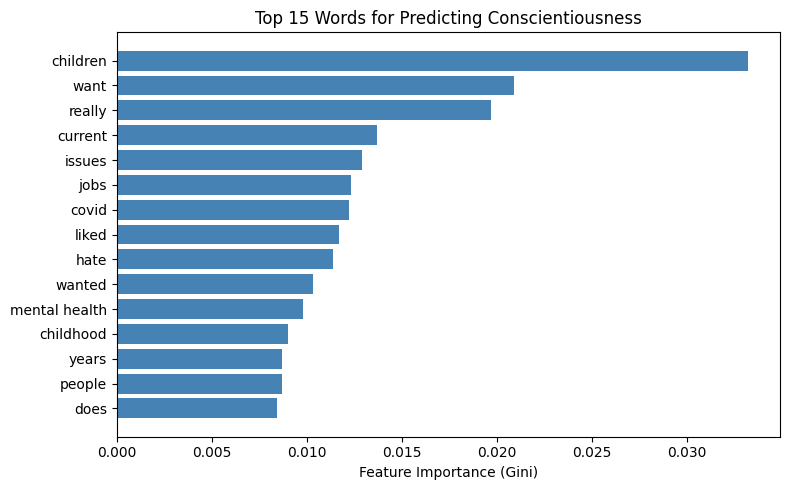

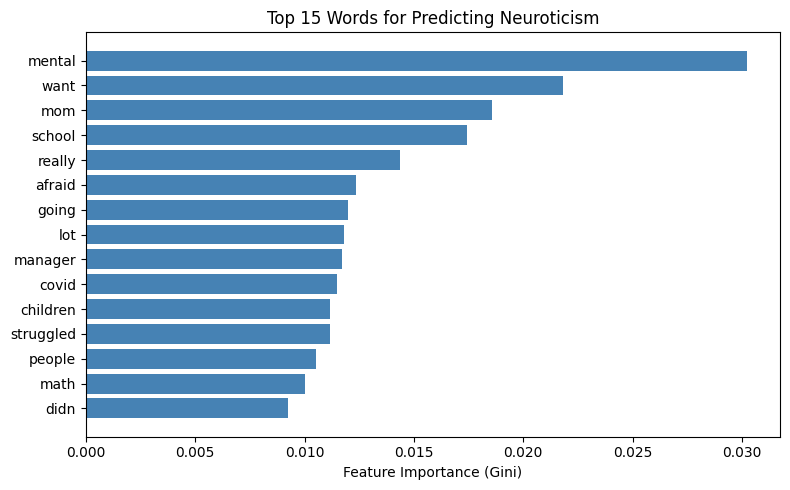

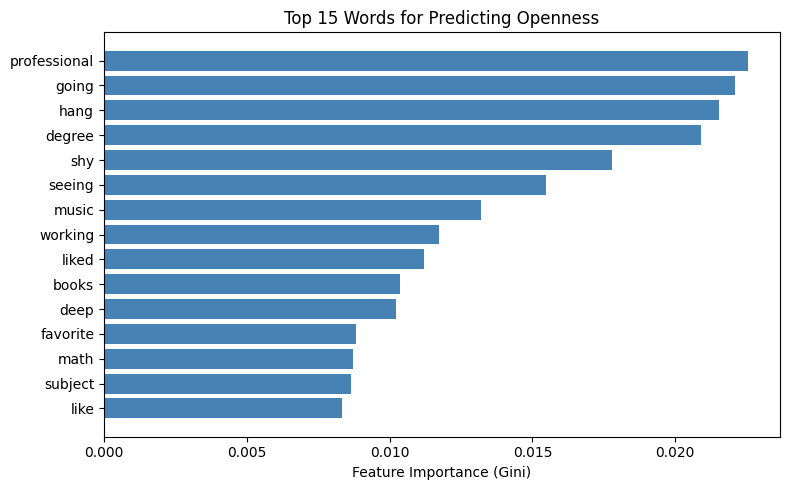

In [26]:
for trait in big_five:
    pipe          = final_pipelines[trait]
    tfidf         = pipe.named_steps["tfidf"]
    rf            = pipe.named_steps["rf"]
    feature_names = tfidf.get_feature_names_out()
    importances   = rf.feature_importances_

    top_idx    = np.argsort(importances)[::-1][:15]
    top_words  = feature_names[top_idx]
    top_scores = importances[top_idx]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(top_words[::-1], top_scores[::-1], color="steelblue")
    ax.set_xlabel("Feature Importance (Gini)")
    ax.set_title(f"Top 15 Words for Predicting {trait}")
    plt.tight_layout()
    plt.show()

## Results analysis 

### Pearson's r Results 

| Trait | Pearson's r |
| --- | ---: |
| Extraversion | `0.298` |
| Agreeableness | `0.030` |
| Conscientiousness | `0.292` |
| Neuroticism | `0.260` |
| Openness | `0.140` |

Random Forest presents best prediction performance for extraversion, conscientiousness and neuroticism, with a weak to moderate convergent validity.

### Key Findings

#### 1. Extraversion Was the Best Predicted Trait

Extraversion had the highest Pearson's r (`0.298`) and one of the strongest R² values. This suggests that narrative responses contain useful cues about sociability, activity preferences, and interpersonal orientation.

Important words included:

- quiet
- friendships
- company
- games
- video games

These likely reflect differences in social engagement and lifestyle.

---

#### 2. Conscientiousness Was Also Predictable

Conscientiousness performed similarly well (`r = 0.292`), suggesting writing style and content may reveal responsibility, planning, and self-regulation.

Important words included:

- currently
- jobs
- years
- wanted
- issues

These may capture structured thinking, goal orientation, and life management themes.

---

#### 3. Neuroticism Showed Meaningful Emotional Signal

Neuroticism had a weak but meaningful correlation (`r = 0.260`).

Important words included:

- mental
- afraid
- struggled
- school
- mom

These suggest emotional stress, anxiety, and personal challenges may appear in narrative language.

---

#### 4. Openness Was Harder to Predict

Openness showed only a very weak relationship (`r = 0.140`).

Important words included:

- music
- books
- degree
- subject
- professional

These words conceptually align with curiosity and intellectual interests, but the predictive signal was limited.

---

#### 5. Agreeableness Was the Hardest Trait to Capture

Agreeableness had near-zero correlation (`r = 0.030`) and negative R², meaning the model did not meaningfully predict this trait.

Although some family/community words appeared important:

- family
- children
- school
- hobbies

the trait may require deeper context, tone, or interaction-based data rather than isolated word frequencies.



